# Urban Infrastructure & Public Safety Modeling

## Purpose

This notebook builds and evaluates machine learning models to analyze the relationship between urban infrastructure and public safety outcomes across Charlotte census tracts.

Specifically, this analysis:

- Builds regression models to predict violent crime counts
- Develops classification models to identify pedestrian-vehicle accident (PVA) hotspots
- Applies cross-validation and hyperparameter tuning to ensure model robustness
- Evaluates statistical significance and interpretability of model predictors

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance


--- Decision Tree ---


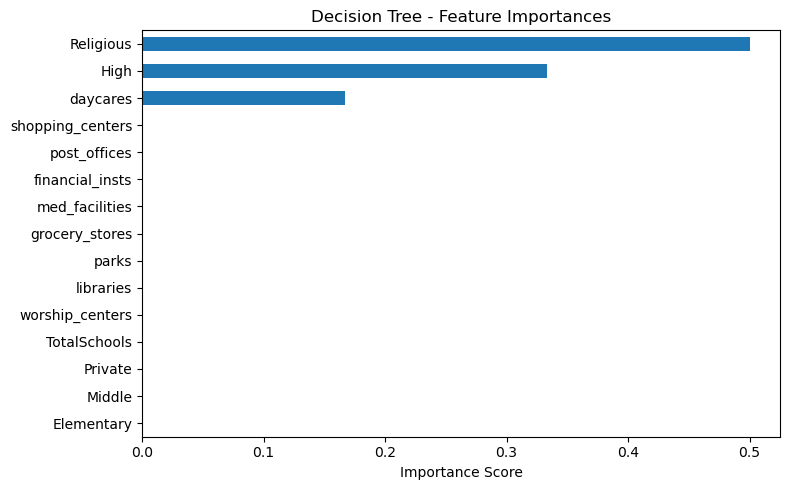

SHAP analysis failed for Decision Tree: The shape of the shap_values matrix does not match the shape of the provided data matrix.

--- SVM ---


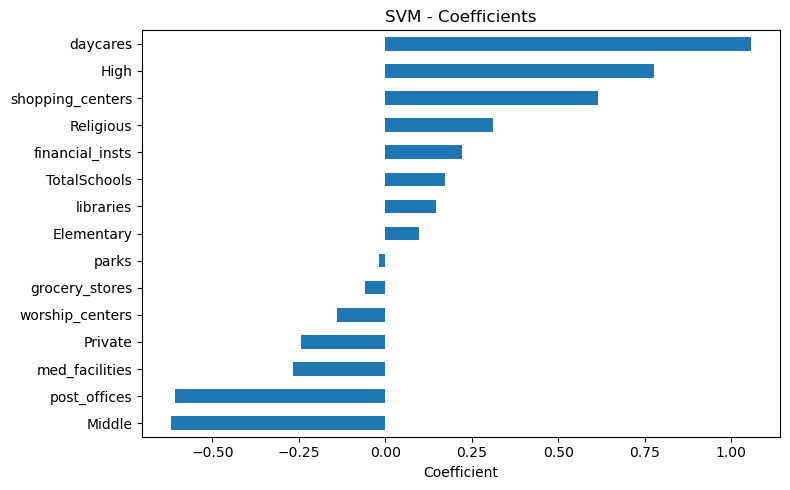

  0%|          | 0/7 [00:00<?, ?it/s]

SHAP analysis failed for SVM: The shape of the shap_values matrix does not match the shape of the provided data matrix.

--- LDA ---


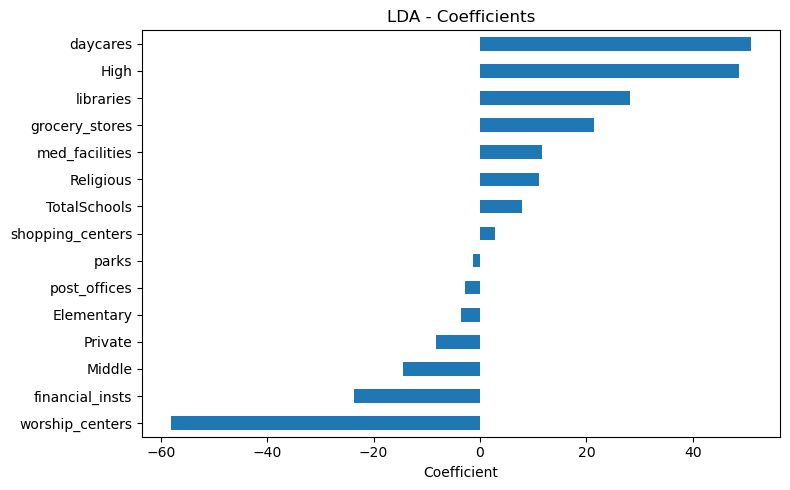

  0%|          | 0/7 [00:00<?, ?it/s]

SHAP analysis failed for LDA: The shape of the shap_values matrix does not match the shape of the provided data matrix.

--- Logistic Regression ---


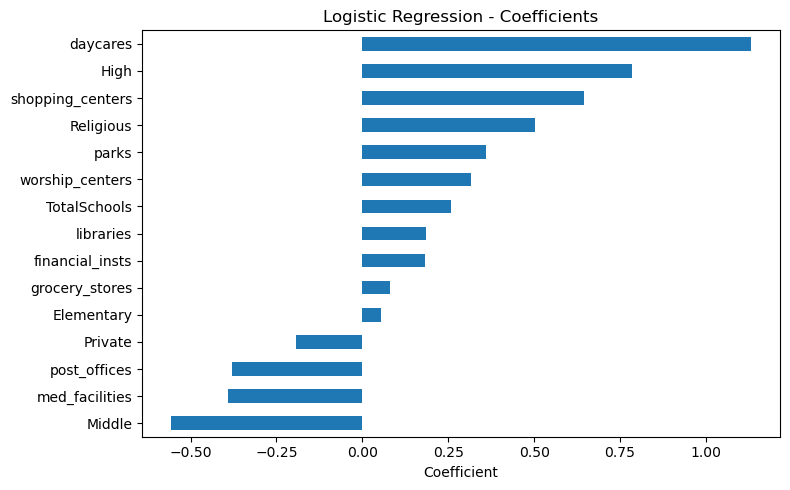

  0%|          | 0/7 [00:00<?, ?it/s]

SHAP analysis failed for Logistic Regression: The shape of the shap_values matrix does not match the shape of the provided data matrix.


<Figure size 640x480 with 0 Axes>

In [15]:
# Required Libraries
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

# Load Data
df = pd.read_csv("zip_code_crime.csv")  # Make sure it's in your current directory
X = df.drop(columns=["Zip", "high_crime"])
y = df["high_crime"]

# Train/Test Split and Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define Classifiers
classifiers = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(kernel='linear', probability=True, random_state=42),  # Needed for SHAP
    "LDA": LinearDiscriminantAnalysis(),
    "Logistic Regression": LogisticRegression(random_state=42)
}

# Train and Analyze Each Classifier
for name, model in classifiers.items():
    print(f"\n--- {name} ---")
    model.fit(X_train_scaled, y_train)

    # Feature Importances (Only if available)
    if hasattr(model, "feature_importances_"):
        importances = pd.Series(model.feature_importances_, index=X.columns)
        importances.sort_values().plot(kind='barh', figsize=(8, 5), title=f'{name} - Feature Importances')
        plt.xlabel("Importance Score")
        plt.tight_layout()
        plt.show()
    
    elif hasattr(model, "coef_"):
        coef = pd.Series(model.coef_[0], index=X.columns)
        coef.sort_values().plot(kind='barh', figsize=(8, 5), title=f'{name} - Coefficients')
        plt.xlabel("Coefficient")
        plt.tight_layout()
        plt.show()

    # SHAP Analysis
    try:
        if name == "Decision Tree":
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_test_scaled)
            shap.summary_plot(shap_values[1], X_test, plot_type="bar", feature_names=X.columns)
        else:
            # KernelExplainer works for all models (but slower)
            explainer = shap.KernelExplainer(model.predict_proba, X_train_scaled[:10])
            shap_values = explainer.shap_values(X_test_scaled[:10])
            shap.summary_plot(shap_values[1], X_test.iloc[:10], plot_type="bar", feature_names=X.columns)
    except Exception as e:
        print(f"SHAP analysis failed for {name}: {e}")
